In [35]:
import numpy as np
import pandas as pd

In [36]:
df = pd.read_csv('titanic_train.csv', usecols = ['Cabin' , 'Ticket' , 'Survived'  , 'SibSp','Parch'])


In [37]:
df['family'] = df['SibSp'] + df['Parch']

In [38]:
df.drop(columns = ['SibSp','Parch'])


,Survived,Ticket,Cabin,family
0,0,A/5 21171,NaN,1
1,1,PC 17599,C85,1
2,1,STON/O2. 3101282,NaN,0
3,1,113803,C123,1
4,0,373450,NaN,0
...,...,...,...,...
886,0,211536,NaN,0
887,1,112053,B42,0
888,0,W./C. 6607,NaN,3
889,1,111369,C148,0


In [39]:
df.dtypes

Survived     int64
SibSp        int64
Parch        int64
Ticket      object
Cabin       object
family       int64
dtype: object

In [40]:
df['family'] = df['family'].replace(0, 'A')


In [41]:
df2 = df.drop(columns = ['SibSp','Parch'])



In [42]:
df2.head()


,Survived,Ticket,Cabin,family
0,0,A/5 21171,NaN,1
1,1,PC 17599,C85,1
2,1,STON/O2. 3101282,NaN,A
3,1,113803,C123,1
4,0,373450,NaN,A


In [43]:
#unique values present in the family column
df2['family'].unique()

array([1, 'A', 4, 2, 6, 5, 3, 7, 10], dtype=object)

Text(0.5, 1.0, 'Passengers travelling with')

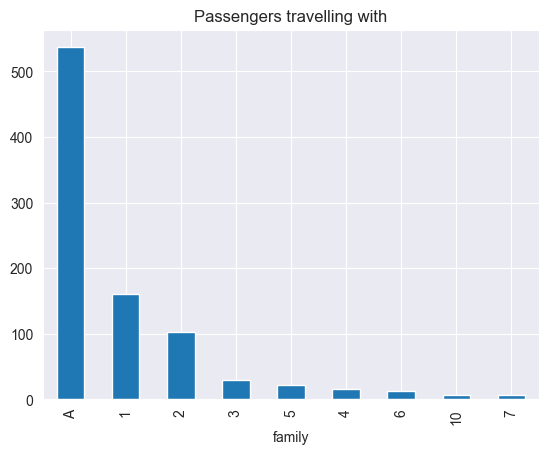

In [44]:
fig = df2['family'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

In [45]:
#extracting numerical part of the mixed variable column, here family
df2['family_numerical'] = pd.to_numeric(df2['family'], errors = 'coerce', downcast = 'integer') #coerce replaces anomalies with NaN

In [46]:
#extracting categorical data
df2['family_categorical'] = np.where(df2['family_numerical'].isnull() , df2['family'], np.nan)
#np.where(condition , x if true , y if false)

In [48]:
df2.sample(15)


,Survived,Ticket,Cabin,family,family_numerical,family_categorical
421,0,A/5. 13032,NaN,A,NaN,A
478,0,350060,NaN,A,NaN,A
689,1,24160,B5,1,1.0,NaN
383,1,113789,NaN,1,1.0,NaN
441,0,345769,NaN,A,NaN,A
426,1,2003,NaN,1,1.0,NaN
114,0,2627,NaN,A,NaN,A
655,0,S.O.C. 14879,NaN,2,2.0,NaN
213,0,250646,NaN,A,NaN,A
709,1,2661,NaN,2,2.0,NaN


In [54]:
df2['Cabin'].unique()


array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [53]:
df2['cabin_num'] = df2['Cabin'].str.extract('(\d+)') #captures numerical part
df2['cabin_cat'] = df2['Cabin'].str[0] #captures the first letter

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_3293/1722228867.py:1: SyntaxWarning: invalid escape sequence '\d'
  df2['cabin_num'] = df['Cabin'].str.extract('(\d+)') #captures numerical part


In [57]:
df2.sample(15)

,Survived,Ticket,Cabin,family,family_numerical,family_categorical,cabin_num,cabin_cat
845,0,C.A. 5547,NaN,A,NaN,A,NaN,NaN
174,0,17764,A7,A,NaN,A,7,A
465,0,SOTON/O.Q. 3101306,NaN,A,NaN,A,NaN,NaN
586,0,237565,NaN,A,NaN,A,NaN,NaN
466,0,239853,NaN,A,NaN,A,NaN,NaN
687,0,349228,NaN,A,NaN,A,NaN,NaN
521,0,349252,NaN,A,NaN,A,NaN,NaN
260,0,384461,NaN,A,NaN,A,NaN,NaN
831,1,29106,NaN,2,2.0,NaN,NaN,NaN
123,1,27267,E101,A,NaN,A,101,E


In [59]:
df2['cabin_cat'].value_counts()


cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

<Axes: xlabel='cabin_cat'>

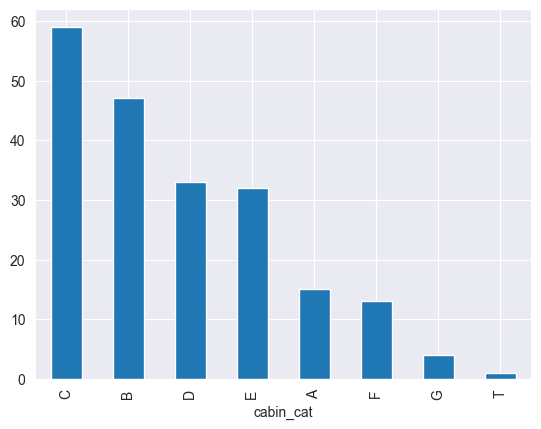

In [60]:
df2['cabin_cat'].value_counts().plot(kind = 'bar')


In [63]:
# extract the last bit of ticket as number
df2['ticket_num'] = df2['Ticket'].apply(lambda s: s.split()[-1])
df2['ticket_num'] = pd.to_numeric(df2['ticket_num'],
                                 errors = 'coerce',
                                 downcast ='integer')

In [65]:
#extract the first part of the ticket as category
df2['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df2['ticket_cat'] = np.where(df2['ticket_cat'].str.isdigit() , np.nan ,df2['ticket_cat'])
df2.head(20)

,Survived,Ticket,Cabin,family,family_numerical,family_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,0,A/5 21171,NaN,1,1.0,NaN,NaN,NaN,21171.0,A/5
1,1,PC 17599,C85,1,1.0,NaN,85,C,17599.0,PC
2,1,STON/O2. 3101282,NaN,A,NaN,A,NaN,NaN,3101282.0,STON/O2.
3,1,113803,C123,1,1.0,NaN,123,C,113803.0,NaN
4,0,373450,NaN,A,NaN,A,NaN,NaN,373450.0,NaN
5,0,330877,NaN,A,NaN,A,NaN,NaN,330877.0,NaN
6,0,17463,E46,A,NaN,A,46,E,17463.0,NaN
7,0,349909,NaN,4,4.0,NaN,NaN,NaN,349909.0,NaN
8,1,347742,NaN,2,2.0,NaN,NaN,NaN,347742.0,NaN
9,1,237736,NaN,1,1.0,NaN,NaN,NaN,237736.0,NaN
